# BAGIAN B: PRAKTIKUM IMPLEMENTASI CNN

## B.1 Dataset dan Setup
Pada bagian ini dilakukan penyiapan *environment* dan dataset yang akan digunakan untuk eksperimen:
* **Framework**: PyTorch
* **Hardware Accelerator**: GPU (CUDA)
* **Dataset**: CIFAR-10 (terdiri dari 60.000 gambar berwarna ukuran $32 \times 32$ piksel dengan 10 kelas objek)
* **Pre-processing**: Konversi gambar menjadi Tensor dan normalisasi nilai piksel menggunakan nilai mean $(0.4914, 0.4822, 0.4465)$ serta standar deviasi $(0.2023, 0.1994, 0.2010)$ agar proses pelatihan berjalan stabil.

In [1]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Cek GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device yang digunakan: {device}")

# Transformasi Data (CIFAR-10)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Download Dataset CIFAR-10
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Device yang digunakan: cuda


100%|██████████| 170M/170M [35:00<00:00, 81.2kB/s]


## B.2 Implementasi Model
Pada bagian ini diimplementasikan dua arsitektur CNN yang berbeda untuk dibandingkan kinerjanya secara adil (*apple-to-apple*):

1. **Model A (Custom CNN Sederhana)**:
   * Terdiri dari 3 blok konvolusi bertingkat (`Conv2D` $\rightarrow$ `BatchNorm` $\rightarrow$ `ReLU` $\rightarrow$ `MaxPool2d`).
   * Menggunakan *Fully Connected Layer* (Dense) berukuran besar di bagian akhir untuk mengklasifikasikan fitur ke 10 kelas output.

2. **Model B (Mini ResNet dengan Residual Connection)**:
   * Menggunakan konsep **Residual Block** dengan fitur *Skip Connection* ($y = F(x) + x$).
   * Menggunakan *Global Average Pooling* di akhir layer konvolusi untuk mereduksi parameter secara signifikan dibanding Fully Connected Layer biasa.
   * *Skip connection* membantu mengatasi masalah *vanishing gradient* dan mempermudah pelatihan jaringan.

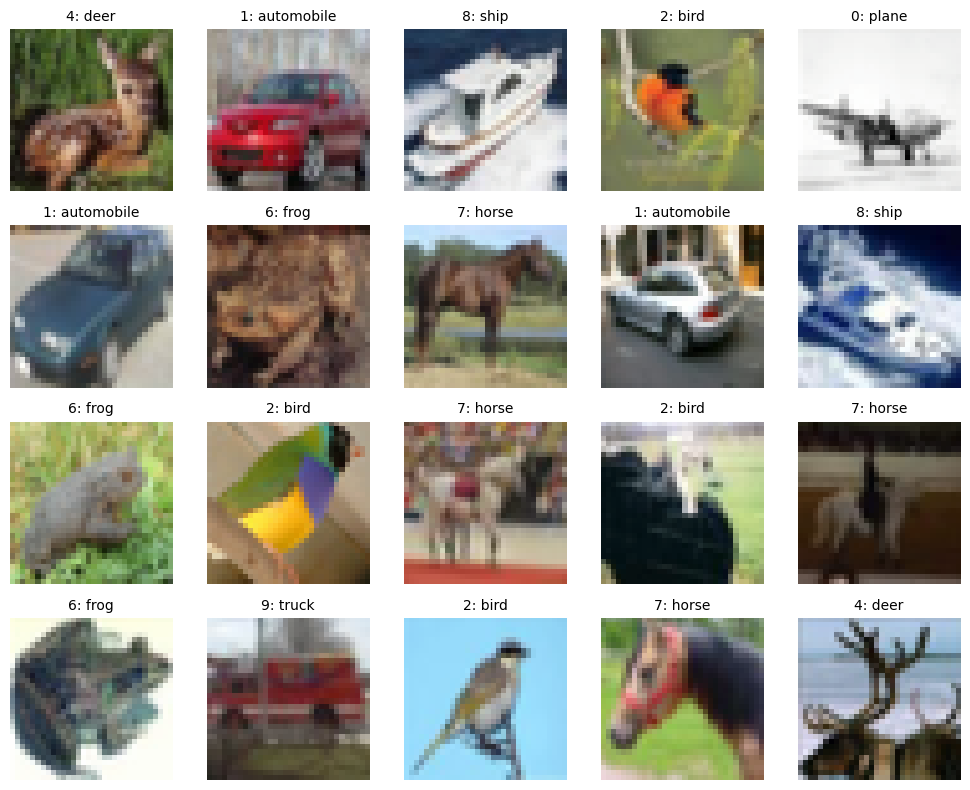

In [5]:
# Unnormalize gambar agar warna kembali normal saat diplot
# Ambil 1 batch data
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Plot grid 4x5 (20 Gambar)
fig = plt.figure(figsize=(10, 8))
for idx in range(20):
    ax = fig.add_subplot(4, 5, idx + 1)

    # Ambil gambar dan denormalisasi sederhana untuk visualisasi
    img = images[idx].numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)

    # Ambil nama kelas berdasarkan label ID
    label_id = labels[idx].item()
    class_name = classes[label_id]

    # Jika nama kelas adalah 'car', ubah teks tampilannya jadi 'automobile' agar persis seperti gambar
    if class_name == 'car':
        class_name = 'automobile'

    label_text = f"{label_id}: {class_name}"

    ax.set_title(label_text, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# --- MODEL A: Custom CNN Sederhana ---
class ModelA_CustomCNN(nn.Module):
    def __init__(self):
        super(ModelA_CustomCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.fc(x)
        return x

# --- MODEL B: Mini ResNet (Residual Connection) ---
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.relu(out)
        return out

class ModelB_MiniResNet(nn.Module):
    def __init__(self):
        super(ModelB_MiniResNet, self).__init__()
        self.prep = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )
        self.layer1 = ResidualBlock(32, 32, stride=1)
        self.layer2 = ResidualBlock(32, 64, stride=2)
        self.layer3 = ResidualBlock(64, 128, stride=2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, 10)

    def forward(self, x):
        x = self.prep(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [8]:
def train_and_evaluate(model, model_name, epochs=10):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(trainset)
        epoch_acc = correct / total
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)

        # Validasi
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        history['val_loss'].append(val_loss / len(testset))
        history['val_acc'].append(val_correct / val_total)

        print(f"[{model_name}] Epoch {epoch+1:02d}/{epochs} | "
              f"Train Acc: {epoch_acc*100:.2f}% | Val Acc: {history['val_acc'][-1]*100:.2f}%")

    total_time = time.time() - start_time

    # Hitung Confusion Matrix
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return history, total_time, cm

# Jalankan Pelatihan Model A dan Model B
model_a = ModelA_CustomCNN()
model_b = ModelB_MiniResNet()

print("=== Training Model A (Custom CNN) ===")
hist_a, time_a, cm_a = train_and_evaluate(model_a, "Model A", epochs=10)

print("\n=== Training Model B (Mini ResNet) ===")
hist_b, time_b, cm_b = train_and_evaluate(model_b, "Model B", epochs=10)

=== Training Model A (Custom CNN) ===
[Model A] Epoch 01/10 | Train Acc: 57.17% | Val Acc: 66.13%
[Model A] Epoch 02/10 | Train Acc: 71.33% | Val Acc: 72.02%
[Model A] Epoch 03/10 | Train Acc: 76.24% | Val Acc: 71.16%
[Model A] Epoch 04/10 | Train Acc: 79.72% | Val Acc: 75.73%
[Model A] Epoch 05/10 | Train Acc: 82.57% | Val Acc: 76.91%
[Model A] Epoch 06/10 | Train Acc: 84.99% | Val Acc: 77.81%
[Model A] Epoch 07/10 | Train Acc: 86.94% | Val Acc: 78.28%
[Model A] Epoch 08/10 | Train Acc: 89.29% | Val Acc: 78.15%
[Model A] Epoch 09/10 | Train Acc: 90.94% | Val Acc: 77.52%
[Model A] Epoch 10/10 | Train Acc: 92.26% | Val Acc: 78.28%

=== Training Model B (Mini ResNet) ===
[Model B] Epoch 01/10 | Train Acc: 53.18% | Val Acc: 54.71%
[Model B] Epoch 02/10 | Train Acc: 67.51% | Val Acc: 63.60%
[Model B] Epoch 03/10 | Train Acc: 73.62% | Val Acc: 71.71%
[Model B] Epoch 04/10 | Train Acc: 77.80% | Val Acc: 75.31%
[Model B] Epoch 05/10 | Train Acc: 80.61% | Val Acc: 75.15%
[Model B] Epoch 06/10 

## B.3 Eksperimen dan Evaluasi
Kedua model dilatih dengan hyperparameter yang identik untuk memastikan perbandingan yang adil:
* **Optimizer**: Adam ($lr = 0.001$)
* **Loss Function**: CrossEntropyLoss
* **Batch Size**: 64
* **Epochs**: 10

### Evaluasi yang Dilaporkan:
1. **Kurva Loss**: Perbandingan Training Loss dan Validation Loss per epoch.
2. **Kurva Akurasi**: Perbandingan Training Accuracy dan Validation Accuracy per epoch.
3. **Akurasi Akhir Test Set**: Performa terbaik model pada data uji.
4. **Jumlah Parameter**: Total parameter yang dapat dilatih (*trainable parameters*).
5. **Waktu Training**: Total durasi eksekusi pelatihan dalam detik.
6. **Confusion Matrix**: Evaluasi rinci prediksi model untuk setiap kelas target.

Total Parameter Model A: 620,810
Total Parameter Model B: 308,682
Waktu Training Model A: 186.78 detik
Waktu Training Model B: 235.70 detik



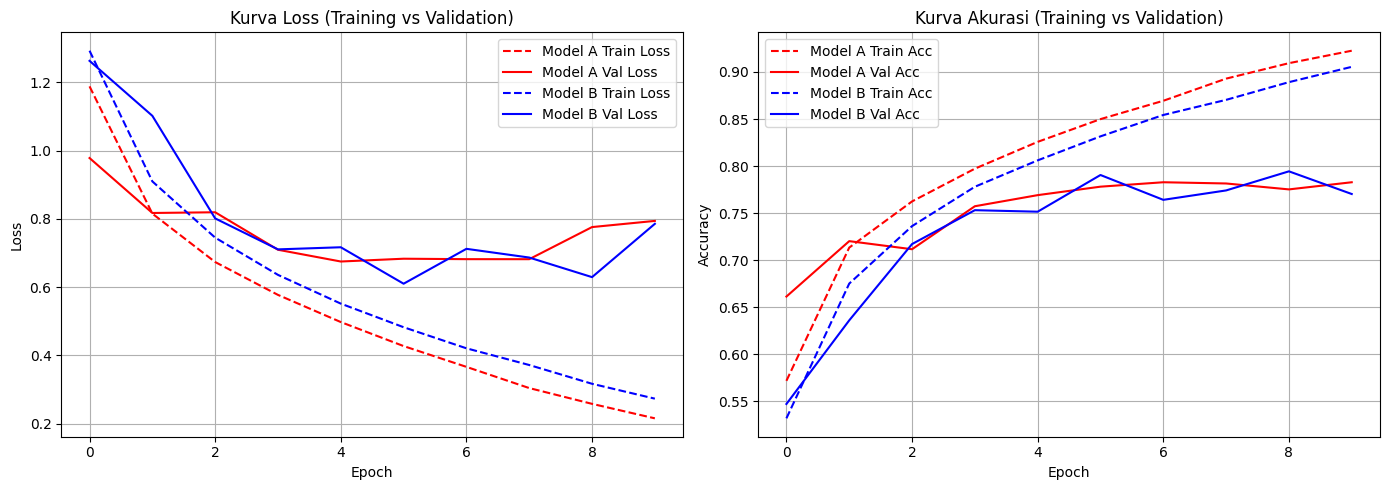

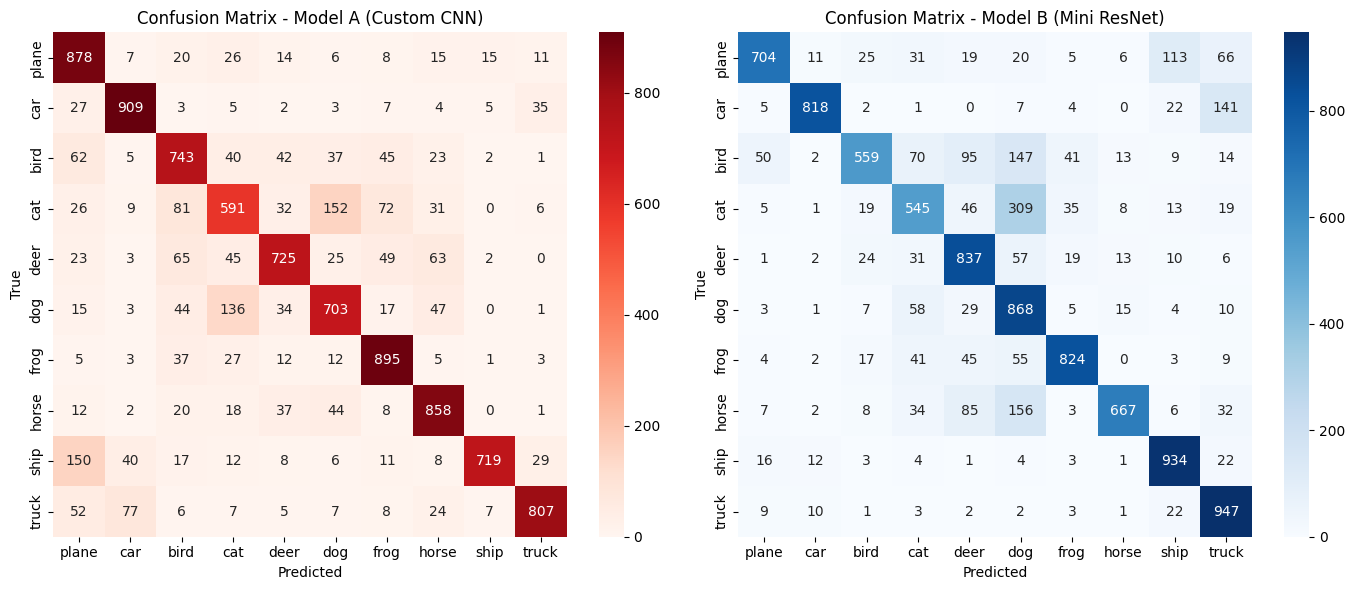

In [9]:
# 1. Jumlah Parameter
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameter Model A: {count_parameters(model_a):,}")
print(f"Total Parameter Model B: {count_parameters(model_b):,}")
print(f"Waktu Training Model A: {time_a:.2f} detik")
print(f"Waktu Training Model B: {time_b:.2f} detik\n")

# 2. Grafik Loss dan Akurasi per Epoch
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_a['train_loss'], 'r--', label='Model A Train Loss')
plt.plot(hist_a['val_loss'], 'r-', label='Model A Val Loss')
plt.plot(hist_b['train_loss'], 'b--', label='Model B Train Loss')
plt.plot(hist_b['val_loss'], 'b-', label='Model B Val Loss')
plt.title('Kurva Loss (Training vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hist_a['train_acc'], 'r--', label='Model A Train Acc')
plt.plot(hist_a['val_acc'], 'r-', label='Model A Val Acc')
plt.plot(hist_b['train_acc'], 'b--', label='Model B Train Acc')
plt.plot(hist_b['val_acc'], 'b-', label='Model B Val Acc')
plt.title('Kurva Akurasi (Training vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Plot Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm_a, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Confusion Matrix - Model A (Custom CNN)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_b, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('Confusion Matrix - Model B (Mini ResNet)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()